In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import requests
from io import BytesIO
from tqdm import tqdm
import os
from google.cloud import storage

from transformers import (
    CLIPModel,
    CLIPProcessor,
    BitsAndBytesConfig
)

from peft import LoraConfig, get_peft_model

/home/MOKART/.cache/pypoetry/virtualenvs/clip-asos-ukri3OAC-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = True

# Load Weights

In [6]:
def download_folder_from_gcs(
    bucket_name,
    gcs_prefix,
    local_folder
):
    client = storage.Client()
    bucket = client.bucket(bucket_name)

    blobs = bucket.list_blobs(prefix=gcs_prefix)

    for blob in blobs:
        if blob.name.endswith("/"):
            continue

        rel_path = os.path.relpath(blob.name, gcs_prefix)
        local_path = os.path.join(local_folder, rel_path)

        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        blob.download_to_filename(local_path)

        print(f"⬇️ gs://{bucket_name}/{blob.name} → {local_path}")

In [7]:
from transformers import CLIPModel, CLIPProcessor
from peft import PeftModel
import torch

BUCKET = "clip-asos-2"
save_dir = "clip_lora_ckpt"

download_folder_from_gcs(
    bucket_name=BUCKET,
    gcs_prefix=f"models/{save_dir}",
    local_folder=save_dir
)

base_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    torch_dtype=torch.float16,
    device_map="auto"
)

model = PeftModel.from_pretrained(
    base_model,
    save_dir,
)

processor = CLIPProcessor.from_pretrained(save_dir)

model.eval()

⬇️ gs://clip-asos-2/models/clip_lora_ckpt/README.md → clip_lora_ckpt/README.md
⬇️ gs://clip-asos-2/models/clip_lora_ckpt/adapter_config.json → clip_lora_ckpt/adapter_config.json
⬇️ gs://clip-asos-2/models/clip_lora_ckpt/adapter_model.safetensors → clip_lora_ckpt/adapter_model.safetensors
⬇️ gs://clip-asos-2/models/clip_lora_ckpt/merges.txt → clip_lora_ckpt/merges.txt
⬇️ gs://clip-asos-2/models/clip_lora_ckpt/preprocessor_config.json → clip_lora_ckpt/preprocessor_config.json
⬇️ gs://clip-asos-2/models/clip_lora_ckpt/special_tokens_map.json → clip_lora_ckpt/special_tokens_map.json


`torch_dtype` is deprecated! Use `dtype` instead!


⬇️ gs://clip-asos-2/models/clip_lora_ckpt/tokenizer.json → clip_lora_ckpt/tokenizer.json
⬇️ gs://clip-asos-2/models/clip_lora_ckpt/tokenizer_config.json → clip_lora_ckpt/tokenizer_config.json
⬇️ gs://clip-asos-2/models/clip_lora_ckpt/vocab.json → clip_lora_ckpt/vocab.json


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


PeftModel(
  (base_model): LoraModel(
    (model): CLIPModel(
      (text_model): CLIPTextTransformer(
        (embeddings): CLIPTextEmbeddings(
          (token_embedding): Embedding(49408, 512)
          (position_embedding): Embedding(77, 512)
        )
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-11): 12 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=512, out_features=512, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=512, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=512, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
   

# TSNE

In [10]:
from sklearn.manifold import TSNE
import numpy as np

def load_image(url, gcs_client, bucket_name):
    filename = url.split('/')[4] + ".png"
    bucket = gcs_client.bucket(bucket_name)
    blob = bucket.blob(f"images/{filename}")
    image_bytes = blob.download_as_bytes()
    image = Image.open(BytesIO(image_bytes)).convert("RGB")
    return image

def extract_image_embeddings(model, dataset, n=100):
    imgs = []
    embs = []

    for i in range(n):
        sample = dataset[i]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
        input_ids = sample["input_ids"].unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(pixel_values=pixel_values, input_ids=input_ids)
            emb = F.normalize(outputs.image_embeds, dim=-1)

        imgs.append(load_image(dataset.df.iloc[i]["im"], dataset.gcs_client, dataset.bucket_name))
        embs.append(emb.cpu().numpy()[0])

    return imgs, np.vstack(embs)

In [12]:
from data_processing import ClipDataset
val_ds = ClipDataset("gs://clip-asos-2/val.csv", processor, BUCKET)
imgs, embs = extract_image_embeddings(model, val_ds, n=100)

tsne = TSNE(
    n_components=2,
    perplexity=15,
    learning_rate="auto",
    init="random",
    random_state=42
)

coords = tsne.fit_transform(embs)

In [13]:
import matplotlib.pyplot as plt

def plot_tsne_canvas(
    images,
    coords,
    width=4000,
    height=3000,
    max_dim=125,
):
    tx, ty = coords[:, 0], coords[:, 1]
    tx = (tx - tx.min()) / (tx.max() - tx.min())
    ty = (ty - ty.min()) / (ty.max() - ty.min())
    full_image = Image.new("RGBA", (width, height), (255, 255, 255, 255))

    for img, x, y in zip(images, tx, ty):
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        img = img.convert("RGBA")

        rs = max(1, img.width / max_dim, img.height / max_dim)
        img = img.resize(
            (int(img.width / rs), int(img.height / rs)),
            Image.LANCZOS
        )

        px = int((width - max_dim) * x)
        py = int((height - max_dim) * y)

        full_image.paste(img, (px, py), mask=img)

    return full_image

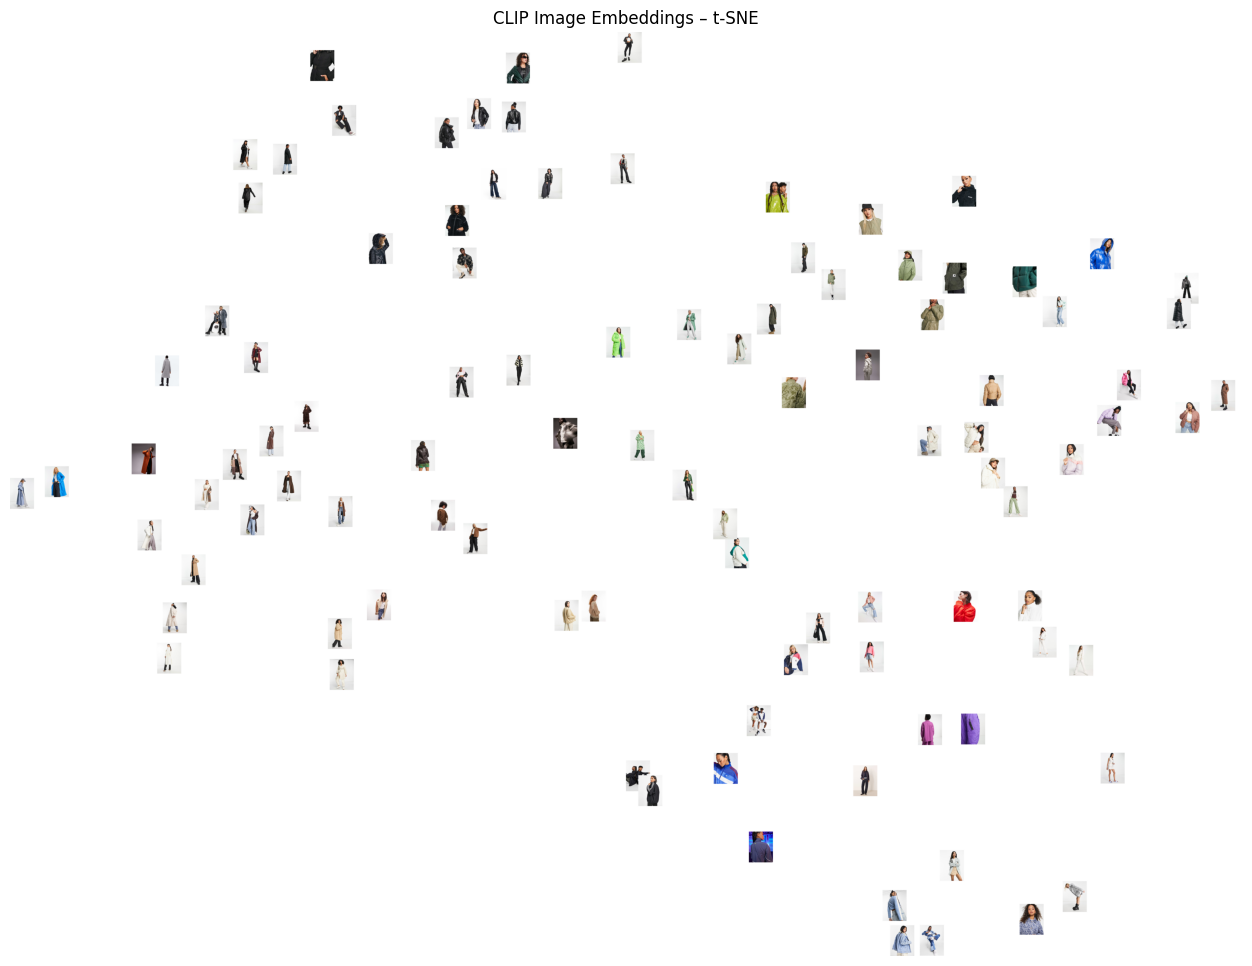

In [14]:
canvas = plot_tsne_canvas(
    images=imgs,
    coords=coords,
    width=4000,
    height=3000,
    max_dim=100
)

plt.figure(figsize=(16, 12))
plt.imshow(canvas)
plt.axis("off")
plt.title("CLIP Image Embeddings – t-SNE")
plt.show()

# TEST : Image similarity and text-to-image retrieval

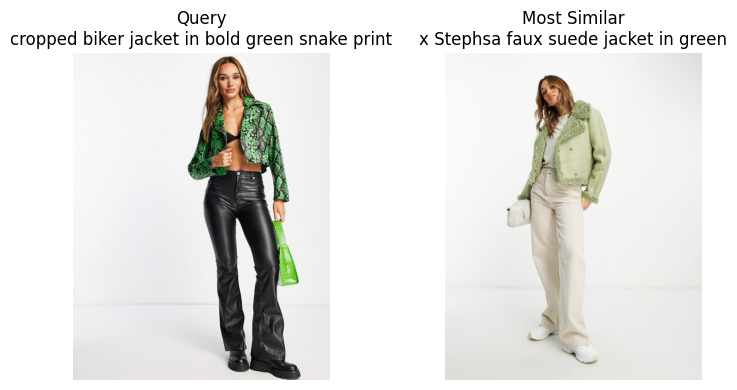

In [25]:
import random

val_df = pd.read_csv("gs://clip-asos-2/val.csv")

# Take a random index from the embeddings
idx = random.randint(0, len(embs) - 1)
query_emb = embs[idx]

# Compute cosine similarity with all other embeddings
similarities = embs @ query_emb / (np.linalg.norm(embs, axis=1) * np.linalg.norm(query_emb))
similarities[idx] = -np.inf  # Exclude self

# Find the most similar index
most_similar_idx = np.argmax(similarities)

# Display the query and most similar image side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(imgs[idx])
axes[0].set_title(f"Query\n{val_df.iloc[idx]['text']}")
axes[0].axis("off")
axes[1].imshow(imgs[most_similar_idx])
axes[1].set_title(f"Most Similar\n{val_df.iloc[most_similar_idx]['text']}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

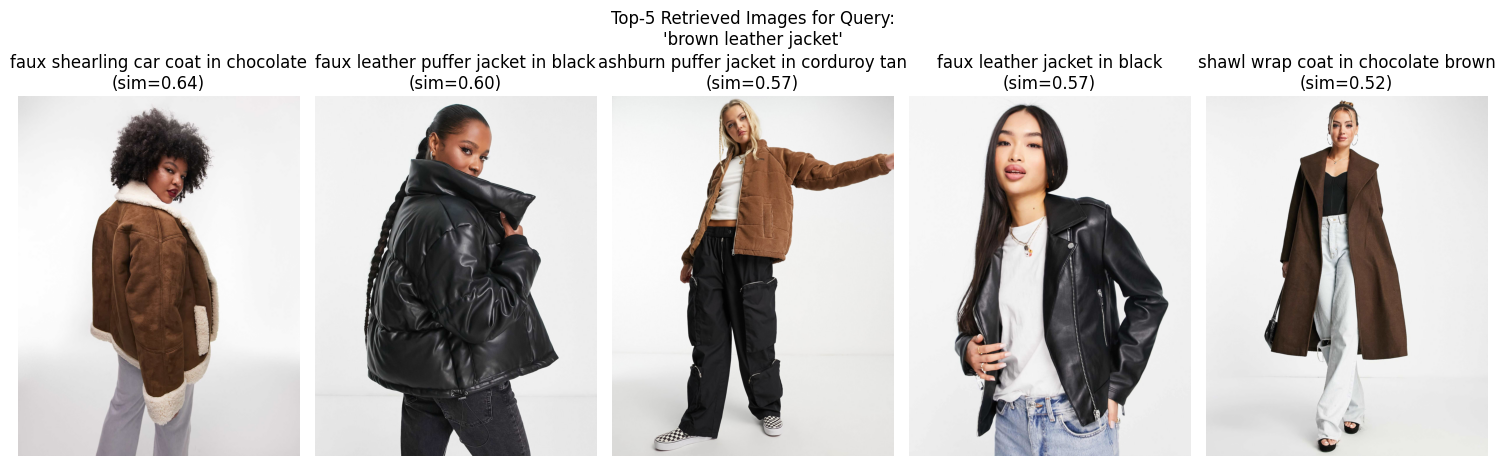

In [31]:
# Text-to-image retrieval: Given a text query, find the most similar image in the embeddings
# Tokenize and encode the text query
text_query = "brown leather jacket"
inputs = processor(text=[text_query], images=None, return_tensors="pt", padding=True)
input_ids = inputs["input_ids"].to(device)

with torch.no_grad():
    text_embeds = model.base_model.get_text_features(input_ids=input_ids)
    text_embeds = F.normalize(text_embeds, dim=-1).cpu().numpy()[0]

# Compute cosine similarity between text embedding and all image embeddings
similarities_text = embs @ text_embeds / (np.linalg.norm(embs, axis=1) * np.linalg.norm(text_embeds))

# Get top 5 most similar images
top_k = 5
top_indices = np.argpartition(similarities_text, -top_k)[-top_k:]
top_indices = top_indices[np.argsort(similarities_text[top_indices])[::-1]]

# Display the top 5 retrieved images and their texts
fig, axes = plt.subplots(1, top_k, figsize=(15, 5))
for i, idx_ in enumerate(top_indices):
    axes[i].imshow(imgs[idx_])
    axes[i].set_title(f"{val_df.iloc[idx_]['text']}\n(sim={similarities_text[idx_]:.2f})")
    axes[i].axis("off")
plt.suptitle(f"Top-{top_k} Retrieved Images for Query:\n'{text_query}'")
plt.tight_layout()
plt.show()